# Preprocessing 

In [205]:
import pandas as pd
import numpy as np

RANDOM_STATE = 568

We will remove the 'Sequence_ID' column since it provides no value to the models

In [206]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess the dataset by dropping unnecessary columns and handling missing values.

    Args:
        df (pd.DataFrame): The input DataFrame to preprocess.

    Returns:
        pd.DataFrame: The preprocessed DataFrame.
    """
    df.drop(columns=['Sequence_ID'], inplace=True)
    feature_names = df.columns[:-1]  # Exclude the last column (label)

    df = df[df[feature_names].sum(axis=1) > 0] # Filter out rows where all features are zero

    df["Virus_Species"] = df["Virus_Species"].apply(lambda x: x.lower())
    num_distinct_species = df["Virus_Species"].value_counts()
    print("Disinct species and their counts before filtering:\n")
    print(num_distinct_species, "\n\n\n")

    valid_classes = [
        "orthohantavirus puumalaense", 
        "orthohantavirus dobravaense", 
        "orthohantavirus hantanense",
        "orthohantavirus sinnombreense"
    ]
    df.drop(df[~df["Virus_Species"].isin(valid_classes)].index, axis=0, inplace=True)
    df.reset_index(drop=True, inplace=True)

    num_distinct_species_after_filtering = df["Virus_Species"].value_counts()
    print("Selected species and their counts after filtering:\n")
    print(num_distinct_species_after_filtering)

    return df

In [207]:
def drop_low_correlation_features(df: pd.DataFrame, feature_names: list[str], threshold=0.9) -> tuple[pd.DataFrame, list[str]]:
    """
    Identifies highly correlated features and drops one of each pair to remove redundancy.

    Args:
        df (pd.DataFrame): The input DataFrame.
        feature_names (list[str]): The original list of feature column names.
        threshold (float): The correlation coefficient threshold above which a feature is dropped.

    Returns:
        tuple[pd.DataFrame, list[str]]: The DataFrame with dropped features and the updated list of feature names.
    """
    print(f"Original number of features: {len(feature_names)}")
    
    corr_matrix = df[feature_names].corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    
    df_filtered = df.drop(columns=to_drop)
    updated_feature_names = [f for f in feature_names if f not in to_drop]
    
    print(f"Updated number of features: {len(updated_feature_names)}\n\n")
    return df_filtered, updated_feature_names

In [208]:
def get_features_and_labels(df: pd.DataFrame, feature_names: list[str]) -> tuple[pd.DataFrame, pd.Series]:
    """
    Extracts features and labels from the given DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        feature_names (list[str]): A list of column names to be used as features.

    Returns:
    tuple[pd.DataFrame, pd.Series]: A tuple containing the features DataFrame and the labels Series.
    """
    X = df[feature_names]
    y_raw = df["Virus_Species"]
    return X, y_raw

In [209]:
from sklearn.preprocessing import LabelEncoder

def encode_labels(y_raw: pd.Series):
    """
    Encodes the labels using LabelEncoder.

    Args:
        y_raw (pd.Series): The raw labels to be encoded.
        label_encoder (LabelEncoder): An instance of LabelEncoder.

    Returns:
        y : array-like of shape (n_samples,)
            Encoded labels.
    """
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw)
    return y, label_encoder

In [210]:
from sklearn.model_selection import train_test_split

def split_data(X, y, test_size=0.1, val_size=0.1, random_state=RANDOM_STATE):
    """
    Splits the data into training, validation, and test sets.

    Args:
        X (pd.DataFrame): The features DataFrame.
        y (array-like): The labels array.
        test_size (float): The proportion of the dataset to include in the test split.
        val_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random seed for reproducibility.

    Returns:
        X_train, X_val, X_test : pd.DataFrame
            The training, validation, and test features DataFrames.
        y_train, y_val, y_test : array-like
            The training, validation, and test labels arrays.
    """
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size, random_state=random_state, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

In [211]:
from sklearn.preprocessing import StandardScaler

def scale_features(X_train, X_val, X_test):
    """
    Scales the features using StandardScaler.

    Args:
        X_train (pd.DataFrame): The training features DataFrame.
        X_val (pd.DataFrame): The validation features DataFrame.
        X_test (pd.DataFrame): The test features DataFrame.

    Returns:
        X_train_scaled, X_val_scaled, X_test_scaled : np.ndarray
            The scaled training, validation, and test features arrays.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_val_scaled, X_test_scaled

We will apply SMOTE (Synthetic Minority Over-sampling Technique) to perform over sampling to fight the class imbalance 

In [212]:
from imblearn.over_sampling import SMOTE

def balance_classes(X_train_scaled, y_train):
    """
    Balances the classes in the training set using SMOTE.

    Args:
        X_train_scaled (np.ndarray): The scaled training features array.
        y_train (array-like): The training labels array.

    Returns:
        X_train_resampled, y_train_resampled : np.ndarray
            The resampled training features and labels arrays.
    """
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
    return X_train_resampled, y_train_resampled

In [213]:
def print_class_distribution(y_train_resampled, label_encoder):
    """
    Prints the distribution of classes in the resampled training labels.

    Args:
        y_train_resampled (array-like): The resampled training labels array.
        label_encoder (LabelEncoder): The fitted LabelEncoder instance.
    """
    print("Class distribution in the resampled training labels:")

    unique, counts = np.unique(y_train_resampled, return_counts=True)
    for label_idx, count in zip(unique, counts):
        species_name = label_encoder.inverse_transform([label_idx])[0]
        print(f"{species_name}: {count}")

# Training the models

In [214]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

MODEL_NAMES = [
    "K-Nearest Neighbors (KNN)",
    "Random Forest",
    "XGBoost",
    "LightGBM",
    "Linear SVM"
]

EARLY_STOPPING_ROUNDS = 10
N_ESTIMATORS = 500
MAX_ITER = 10000

optimal_models = {}
accuracy_results = {}
confusion_matrices = {}

In [215]:
def create_model(model_name, params):
    """
    Creates a machine learning model based on the specified model name and parameters.

    Args:
        model_name (str): The name of the model to create.
        params (dict): A dictionary of hyperparameters for the model.

    Returns:
        model : object
            The created machine learning model.
    """
    model = None
    if model_name == "K-Nearest Neighbors (KNN)":
        model = KNeighborsClassifier(**params)
    elif model_name == "Random Forest":
        model = RandomForestClassifier(**params, random_state=RANDOM_STATE)
    elif model_name == "XGBoost":
        model = XGBClassifier(
            **params, 
            n_estimators=N_ESTIMATORS, 
            random_state=RANDOM_STATE, 
            eval_metric="mlogloss", 
            early_stopping_rounds=EARLY_STOPPING_ROUNDS, 
            n_jobs=-1
        )
    elif model_name == "LightGBM":
        model = LGBMClassifier(
            **params, 
            n_estimators=N_ESTIMATORS, 
            random_state=RANDOM_STATE, 
            verbosity=-1, 
            n_jobs=-1
        )
    else: 
        model = LinearSVC(**params, random_state=RANDOM_STATE, max_iter=MAX_ITER)
    return model

In [216]:
import itertools

def train_models(
    X_train_resampled: pd.DataFrame, 
    X_val_scaled: pd.DataFrame,
    X_test_scaled: pd.DataFrame,
    y_train_resampled: np.ndarray, 
    y_val: np.ndarray, 
    feature_names: list[str]
) -> None:
    """
    Tunes expanded combinations of hyperparameters on the validation split, handles XGBoost's 
    early stopping safely, and instantiates the finalized models without argument conflicts.

    Args:
        X_train_resampled (pd.DataFrame): The resampled training features DataFrame.
        X_val_scaled (pd.DataFrame): The validation features DataFrame.
        X_test_scaled (pd.DataFrame): The test features DataFrame.
        y_train_resampled (np.ndarray): The resampled training labels array.
        y_val (np.ndarray): The validation labels array.
        feature_names (list[str]): A list of column names used as features.

    Returns:
        None
    """
    X_train_resampled = pd.DataFrame(X_train_resampled, columns=feature_names)
    X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

    tuning_grid = {
            "K-Nearest Neighbors (KNN)": {
                "n_neighbors": [3, 5, 7, 9, 11], 
                "weights": ["uniform", "distance"]
            },
            "Random Forest": {
                "max_depth": [5, 10, 15, 20, None], 
                "min_samples_split": [2, 5, 10, 15, 20]
            },
            "XGBoost": {
                "max_depth": [3, 5, 7, 9, 11], 
                "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2]
            },
            "LightGBM": {
                "num_leaves": [15, 31, 63, 127, 255], 
                "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2]
            },
            "Linear SVM": {
                "C": [0.01, 0.1, 1.0, 10.0, 100.0]
            }
    }

    print("\nStarting hyperparameter tuning and model training...\n")

    for model_name in MODEL_NAMES:
        best_accuracy = -1
        best_params = {}
        grid = tuning_grid[model_name]
        
        keys, values = zip(*grid.items())
        experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

        for params in experiments:
            current_params = params.copy()
            model = create_model(model_name, current_params)

            if model_name == "XGBoost":
                model.fit(
                    X_train_resampled, 
                    y_train_resampled, 
                    eval_set=[(X_val_scaled, y_val)], 
                    verbose=False
                )
                current_params["n_estimators"] = model.best_iteration + 1
            else:
                model.fit(X_train_resampled, y_train_resampled)

            y_val_pred = model.predict(X_val_scaled)
            accuracy = accuracy_score(y_val, y_val_pred)

            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = current_params

        print(f"Optimal {model_name} parameters: {best_params}")
        
        final_xgb_trees = best_params.pop("n_estimators", None)
        final_model = create_model(model_name, best_params)
        
        if model_name == "XGBoost" and final_xgb_trees is not None:
            final_model.set_params(early_stopping_rounds=None, n_estimators=final_xgb_trees)
            final_model.fit(X_train_resampled, y_train_resampled)
        else:
            final_model.fit(X_train_resampled, y_train_resampled)

        optimal_models[model_name] = final_model

In [217]:
def evaluate_model(model, name, X_test, y_test, label_encoder):
    """
    Evaluates a trained model on the test dataset, computes performance metrics,
    stores the results globally, and prints a comprehensive classification report.

    Parameters:
        model : estimator object
            The trained classification model to evaluate.
        name : str
            The identifier name of the model used as a key for storing results.
        X_test : array-like or DataFrame
            The scaled feature matrix for the testing dataset.
        y_test : array-like
            The true integer labels for the testing dataset.
        label_encoder : LabelEncoder
            The fitted LabelEncoder instance used to map integer labels back 
            to the original biological virus species names.

    Returns:
        None
    """
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
    
    accuracy_results[name] = acc
    confusion_matrices[name] = conf_matrix

    print(f"Final Evaluation for optimized model: {name}")
    print(class_report)

In [218]:
def print_confusion_matrices(
    X_test_scaled, 
    y_test,
    label_encoder
):
    """
    Prints the confusion matrices for all evaluated models.

    Returns:
        None
    """
    print("\nConfusion Matrices:")
    for model_name in MODEL_NAMES:
        model = optimal_models[model_name]
        evaluate_model(model, model_name, X_test_scaled, y_test, label_encoder)

# Plot the accuracy performance

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_accuracy_results(accuracy_results):
    """
    Plots a sorted bar chart of the accuracy results for all evaluated models.

    Args:
        accuracy_results (dict): A dictionary containing model names as keys and 
                                 their corresponding accuracy scores as values.

    Returns:
        None
    """
    sorted_results = sorted(accuracy_results.items(), key=lambda item: item[1], reverse=True)
    names, values = zip(*sorted_results)

    plt.figure(figsize=(12, 5))
    sns.barplot(
        x=list(names), 
        y=list(values), 
        palette="YlGnBu", 
        hue=list(names), 
        legend=False
    )
    
    plt.title("Test Accuracy for Models Optimized via Validation Splits", fontsize=14, pad=15)
    plt.ylabel("Accuracy Score (0.0 - 1.0)", fontsize=12)
    plt.xlabel("Optimized Classifiers", fontsize=12)
    plt.ylim(0, 1.1)

    for idx, val in enumerate(values):
        plt.text(idx, val + 0.02, f"{val:.4f}", ha="center", fontweight="bold", fontsize=11)

    plt.tight_layout()
    plt.show()

In [220]:
def plot_single_confusion_matrix(matrix, model_name, class_names):
    """
    Plots a single confusion matrix heatmap using a standardized professional palette.

    Args:
        matrix: The calculated confusion matrix array.
        model_name: String name of the model for the plot title.
        class_names: List of target class labels for axis ticks.
    """
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matrix, 
        annot=True, 
        fmt="d", 
        cmap="YlGnBu", 
        xticklabels=class_names, 
        yticklabels=class_names,
        cbar=False,
        annot_kws={"size": 12, "weight": "bold"}
    )
    plt.title(f"Confusion Matrix: {model_name}", fontsize=13, pad=12, fontweight="bold")
    plt.ylabel("Ground Truth Class", fontsize=11)
    plt.xlabel("Predicted Class", fontsize=11)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [221]:
def plot_all_confusion_matrices(confusion_matrices, label_encoder):
    """
    Plots confusion matrices for all evaluated models.

    Args:
        confusion_matrices (dict): A dictionary containing model names as keys and their corresponding confusion matrices as values.
        label_encoder (LabelEncoder): The fitted LabelEncoder instance used to map integer labels back to the original biological virus species names.

    Returns:
        None
    """
    for model_name, matrix in confusion_matrices.items():
        plot_single_confusion_matrix(matrix, model_name, label_encoder.classes_)

# Wrapping everything in a single function

In [222]:
def train_and_evaluate(df, feature_names):
    """
    Orchestrates the entire machine learning workflow: data preparation, model training, evaluation, and visualization.

    Returns:
        None
    """
    X, y_raw = get_features_and_labels(df, feature_names)
    y, label_encoder = encode_labels(y_raw)
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    X_train_scaled, X_val_scaled, X_test_scaled = scale_features(X_train, X_val, X_test)
    X_train_resampled, y_train_resampled = balance_classes(X_train_scaled, y_train)

    print_class_distribution(y_train_resampled, label_encoder)
    
    # To suppress the warning: X does not have valid feature names, but <model> was fitted with feature names
    X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=feature_names)
    X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=feature_names)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

    train_models(X_train_resampled_df, X_val_scaled_df, X_test_scaled_df, y_train_resampled, y_val, feature_names)
    
    print_confusion_matrices(X_test_scaled_df, y_test, label_encoder)
    
    plot_accuracy_results(accuracy_results)
    
    plot_all_confusion_matrices(confusion_matrices, label_encoder)

# All sequences dataset

In [223]:
import os

CURRENT_DIR = os.path.dirname(os.path.abspath("__file__"))
ALL_SEQUENCES_DATASET_PATH = os.path.join(CURRENT_DIR, 'data', "dataset_all_sequences.csv")

In [224]:
df: pd.DataFrame = pd.read_csv(ALL_SEQUENCES_DATASET_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7087 entries, 0 to 7086
Data columns (total 79 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sequence_ID     7087 non-null   str    
 1   dc_total_count  7087 non-null   float64
 2   dc_avg_length   7087 non-null   float64
 3   dc_max_length   7087 non-null   float64
 4   dc_len_5        7087 non-null   float64
 5   dc_len_6        7087 non-null   float64
 6   dc_len_7        7087 non-null   float64
 7   dc_len_8        7087 non-null   float64
 8   dc_len_9        7087 non-null   float64
 9   dc_len_10       7087 non-null   float64
 10  dc_len_11       7087 non-null   float64
 11  dc_len_12       7087 non-null   float64
 12  dc_len_13       7087 non-null   float64
 13  dc_len_14       7087 non-null   float64
 14  dc_len_15       7087 non-null   float64
 15  dc_len_16       7087 non-null   float64
 16  dc_len_17       7087 non-null   float64
 17  dc_len_18       7087 non-null   float64
 18 

In [225]:
df.describe()

,dc_total_count,dc_avg_length,dc_max_length,dc_len_5,dc_len_6,dc_len_7,dc_len_8,dc_len_9,dc_len_10,dc_len_11,...,in_len_17,in_len_18,in_len_19,in_len_20,in_len_21,in_len_22,in_len_23,in_len_27,in_len_29,in_len_30
count,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,...,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000,7087.000000
mean,92.704812,2.158522,2.444476,76.499224,12.774093,2.568506,0.640751,0.165091,0.037957,0.011570,...,0.017779,0.016086,0.020883,0.001552,0.001411,0.000282,0.011994,0.000282,0.000564,0.000282
std,887.456247,2.651432,3.057542,599.932559,209.210233,63.828865,15.714875,4.366870,0.719942,0.198446,...,0.191463,0.142637,0.144964,0.039369,0.037540,0.016798,0.108865,0.016798,0.023752,0.016798
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,14.000000,5.053011,6.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,45314.000000,11.000000,19.000000,29871.000000,11099.000000,3319.000000,771.000000,220.000000,26.000000,8.000000,...,7.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [226]:
df.head()

,Sequence_ID,dc_total_count,dc_avg_length,dc_max_length,dc_len_5,dc_len_6,dc_len_7,dc_len_8,dc_len_9,dc_len_10,...,in_len_18,in_len_19,in_len_20,in_len_21,in_len_22,in_len_23,in_len_27,in_len_29,in_len_30,Virus_Species
0,AB010730.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense
1,AB010731.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense
2,AB010732.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense
3,AB010733.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense
4,AB010734.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Orthohantavirus puumalaense


In [227]:
df = preprocess_data(df)
feature_names = df.columns[:-1]

Disinct species and their counts before filtering:

Virus_Species
orthohantavirus puumalaense      3562
orthohantavirus hantanense       2056
orthohantavirus dobravaense       764
orthohantavirus sinnombreense     276
hokkaido virus                     78
                                 ... 
jp 2025084850-a/6:                  1
jp 2025084850-a/8:                  1
jp 2025084850-a/18:                 1
jp 2025084850-a/19:                 1
jp 2025084850-a/20:                 1
Name: count, Length: 144, dtype: int64 



Selected species and their counts after filtering:

Virus_Species
orthohantavirus puumalaense      3562
orthohantavirus hantanense       2056
orthohantavirus dobravaense       764
orthohantavirus sinnombreense     276
Name: count, dtype: int64


Class distribution in the resampled training labels:
orthohantavirus dobravaense: 2885
orthohantavirus hantanense: 2885
orthohantavirus puumalaense: 2885
orthohantavirus sinnombreense: 2885

Starting hyperparameter tuning and model training...

Optimal K-Nearest Neighbors (KNN) parameters: {'n_neighbors': 3, 'weights': 'distance'}
Optimal Random Forest parameters: {'max_depth': None, 'min_samples_split': 2}
Optimal XGBoost parameters: {'max_depth': 7, 'learning_rate': 0.1, 'n_estimators': 291}
Optimal LightGBM parameters: {'num_leaves': 63, 'learning_rate': 0.1}
Optimal Linear SVM parameters: {'C': 10.0}

Confusion Matrices:
Final Evaluation for optimized model: K-Nearest Neighbors (KNN)
                               precision    recall  f1-score   support

  orthohantavirus dobravaense       0.76      0.82      0.78        76
   orthohantavirus hantanense       0.86      0.90      0.88       206
  orthohantavirus puumalaense       0.94      0.90      0.92       356
orthohantavirus si

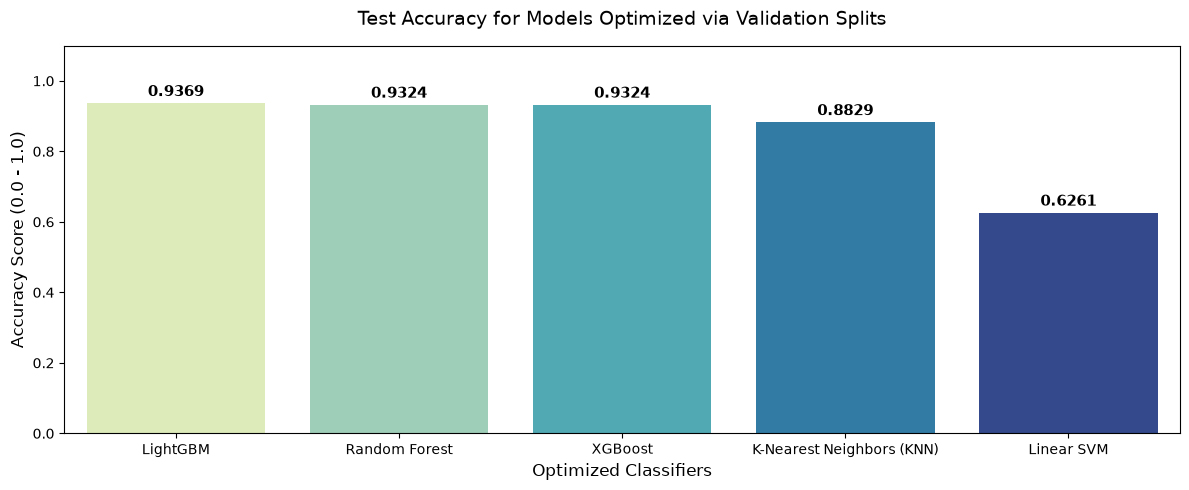

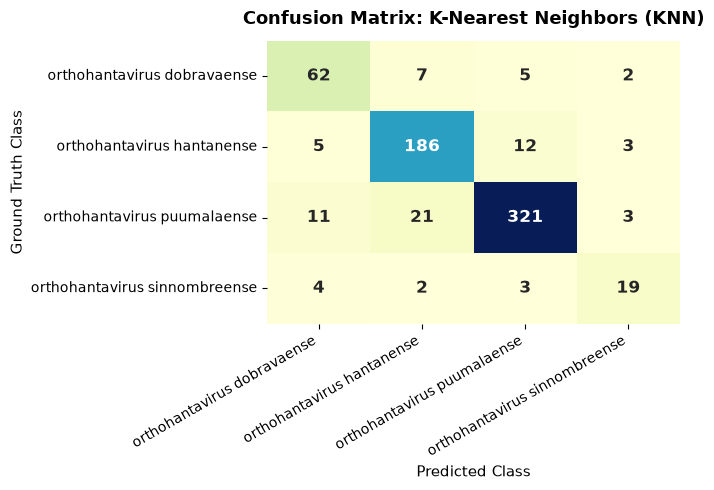

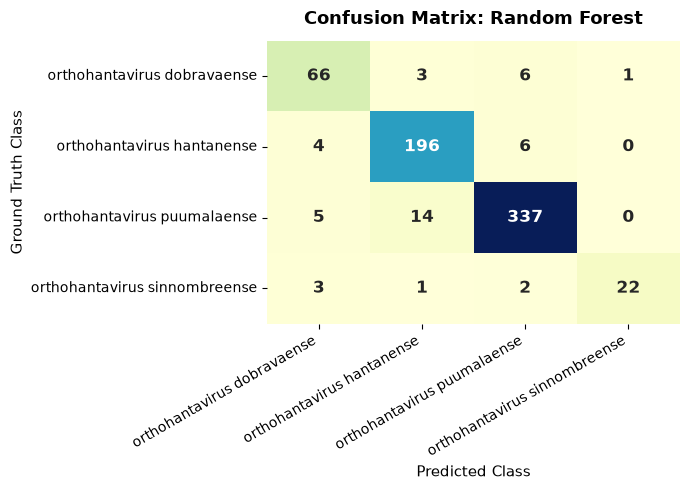

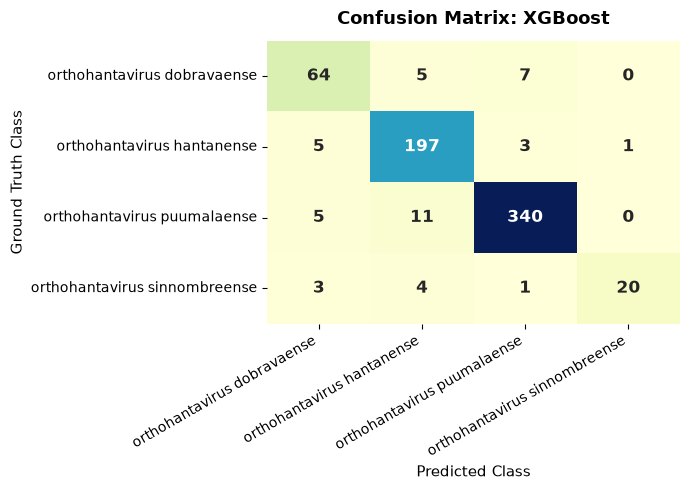

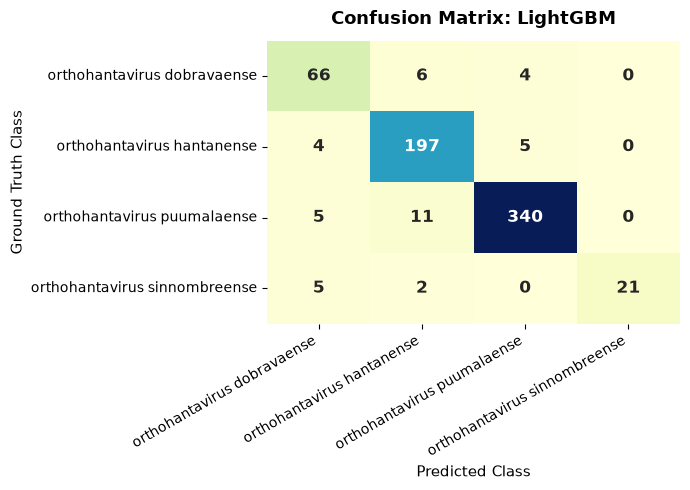

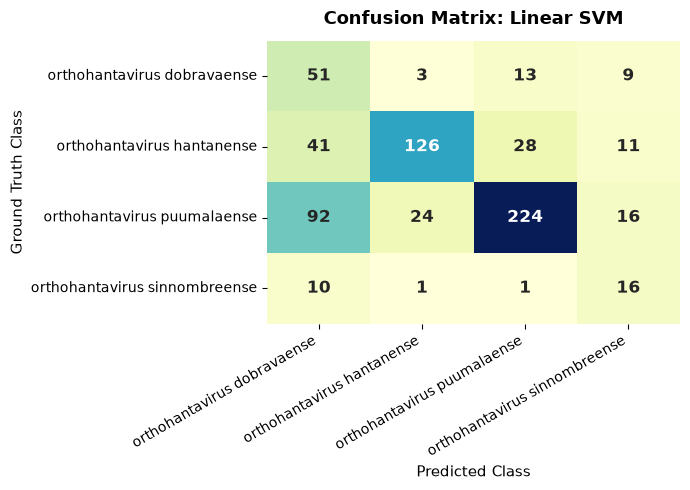

In [228]:
train_and_evaluate(df, feature_names)

## Feature selection

Original number of features: 77
Updated number of features: 58


Class distribution in the resampled training labels:
orthohantavirus dobravaense: 2885
orthohantavirus hantanense: 2885
orthohantavirus puumalaense: 2885
orthohantavirus sinnombreense: 2885

Starting hyperparameter tuning and model training...

Optimal K-Nearest Neighbors (KNN) parameters: {'n_neighbors': 5, 'weights': 'distance'}
Optimal Random Forest parameters: {'max_depth': None, 'min_samples_split': 2}
Optimal XGBoost parameters: {'max_depth': 9, 'learning_rate': 0.2, 'n_estimators': 163}
Optimal LightGBM parameters: {'num_leaves': 255, 'learning_rate': 0.03}
Optimal Linear SVM parameters: {'C': 0.1}

Confusion Matrices:
Final Evaluation for optimized model: K-Nearest Neighbors (KNN)
                               precision    recall  f1-score   support

  orthohantavirus dobravaense       0.67      0.79      0.72        76
   orthohantavirus hantanense       0.83      0.89      0.86       206
  orthohantavirus puuma

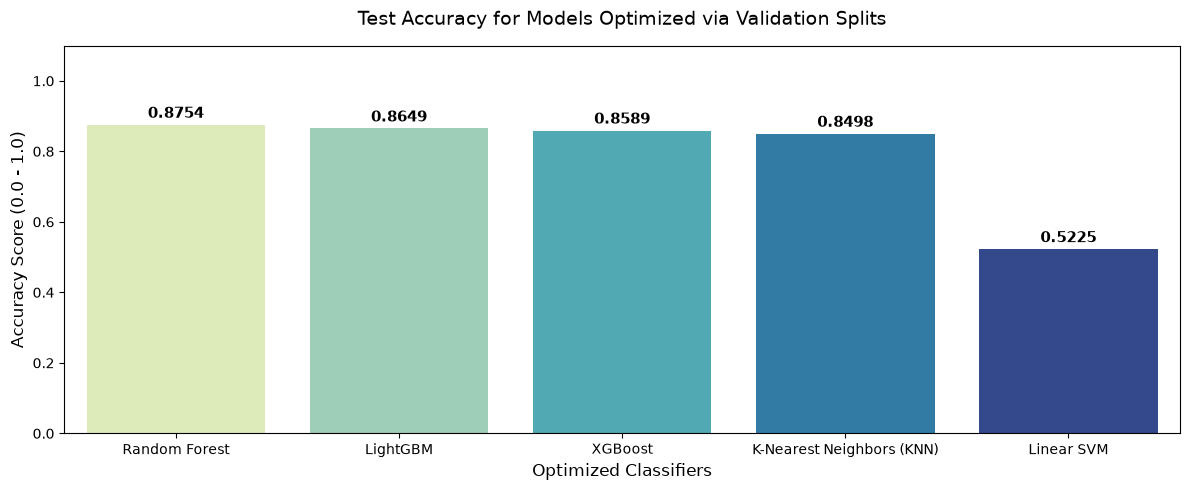

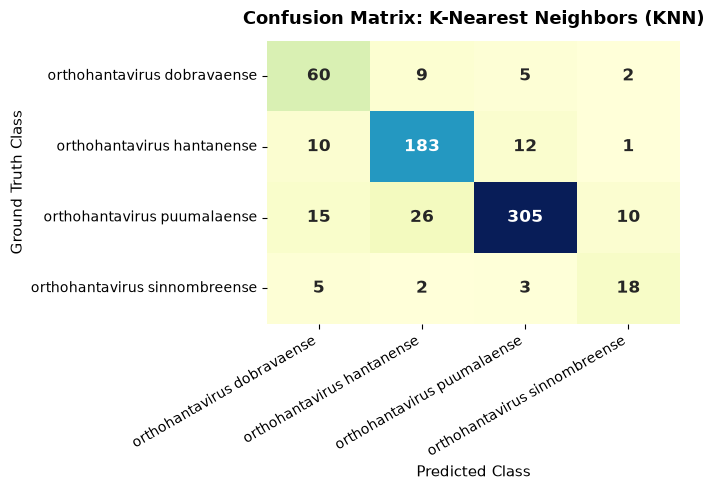

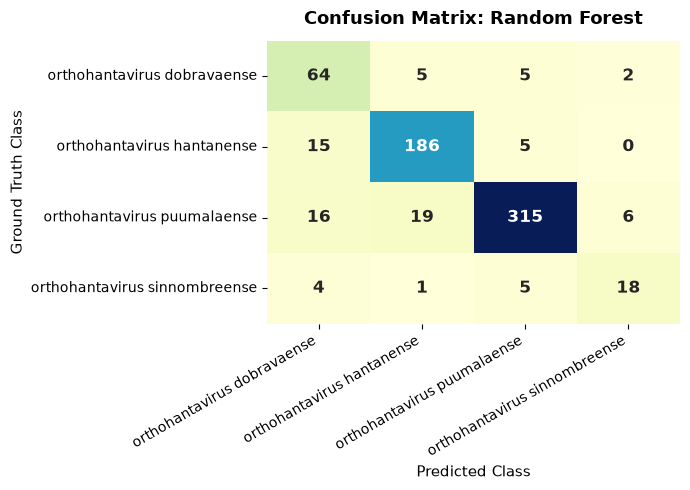

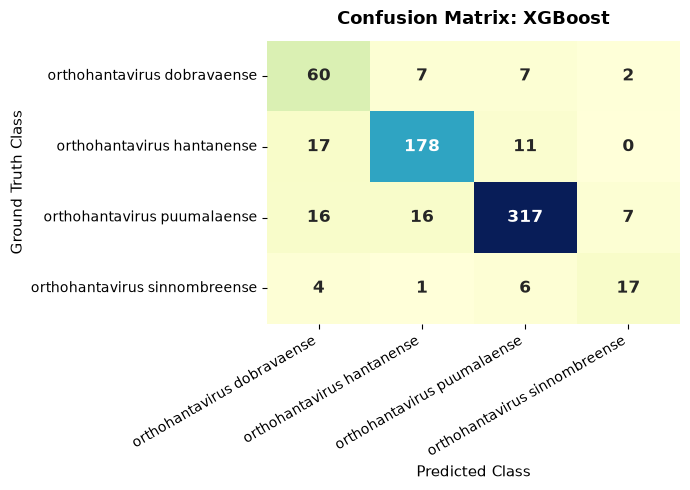

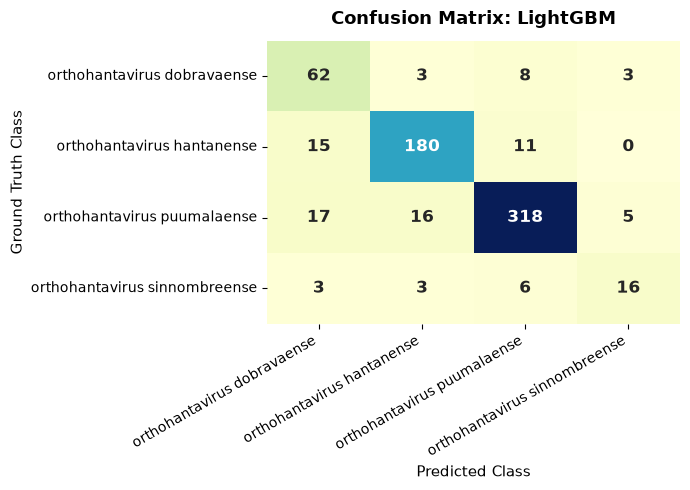

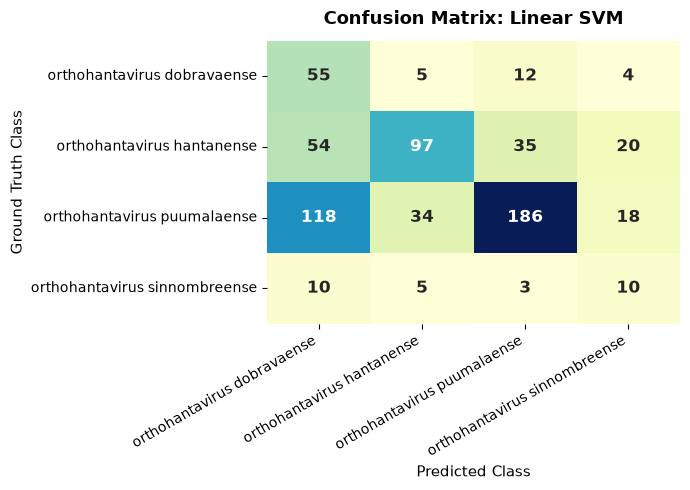

In [229]:
df_without_corr, feature_names_without_corr = drop_low_correlation_features(df, feature_names)
train_and_evaluate(df_without_corr, feature_names_without_corr)

# Complete sequences dataset

In [230]:
COMPLETE_SEQUENCES_DATASET_PATH = os.path.join(CURRENT_DIR, 'data', "dataset_complete_sequences.csv")
df: pd.DataFrame = pd.read_csv(COMPLETE_SEQUENCES_DATASET_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 73 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sequence_ID     435 non-null    str    
 1   dc_total_count  435 non-null    int64  
 2   dc_avg_length   435 non-null    float64
 3   dc_max_length   435 non-null    int64  
 4   dc_len_5        435 non-null    int64  
 5   dc_len_6        435 non-null    int64  
 6   dc_len_7        435 non-null    int64  
 7   dc_len_8        435 non-null    int64  
 8   dc_len_9        435 non-null    int64  
 9   dc_len_10       435 non-null    int64  
 10  dc_len_11       435 non-null    int64  
 11  dc_len_12       435 non-null    int64  
 12  dc_len_13       435 non-null    int64  
 13  dc_len_14       435 non-null    int64  
 14  dc_len_15       435 non-null    int64  
 15  dc_len_16       435 non-null    int64  
 16  dc_len_17       435 non-null    int64  
 17  dc_len_18       435 non-null    int64  
 18  d

In [231]:
df.describe()

,dc_total_count,dc_avg_length,dc_max_length,dc_len_5,dc_len_6,dc_len_7,dc_len_8,dc_len_9,dc_len_10,dc_len_11,...,in_len_12,in_len_13,in_len_14,in_len_15,in_len_16,in_len_17,in_len_18,in_len_19,in_len_23,in_len_29
count,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,...,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000,435.000000
mean,4555.137931,5.327800,10.747126,3422.873563,822.655172,224.443678,53.914943,23.236782,6.013793,1.425287,...,0.668966,0.542529,0.342529,0.388506,0.032184,0.041379,0.027586,0.082759,0.087356,0.002299
std,4865.822505,0.082903,2.855258,3661.914632,851.103063,262.698261,85.862336,31.763259,9.133409,2.828558,...,1.782099,0.933211,0.555582,0.660510,0.176691,0.199395,0.163973,0.275834,0.282682,0.047946
min,8.000000,5.079439,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,321.000000,5.292250,8.000000,258.500000,67.000000,16.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2678.000000,5.327492,10.000000,1986.000000,521.000000,96.000000,8.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10785.000000,5.361464,13.000000,8146.000000,1827.500000,551.000000,67.000000,64.000000,17.000000,0.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,13846.000000,6.368421,18.000000,10254.000000,2628.000000,784.000000,315.000000,89.000000,28.000000,10.000000,...,11.000000,5.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [232]:
df.head()

,Sequence_ID,dc_total_count,dc_avg_length,dc_max_length,dc_len_5,dc_len_6,dc_len_7,dc_len_8,dc_len_9,dc_len_10,...,in_len_13,in_len_14,in_len_15,in_len_16,in_len_17,in_len_18,in_len_19,in_len_23,in_len_29,Virus_Species
0,AY017064.1,264,5.340909,8,196,48,18,2,0,0,...,1,0,0,0,0,0,0,0,0,Orthohantavirus hantanense
1,AY526217.1,11591,5.379864,10,8624,1975,648,261,66,17,...,0,1,0,0,1,0,0,0,0,Orthohantavirus puumalaense
2,AY526218.1,3034,5.379038,12,2134,744,109,12,25,9,...,0,1,1,0,0,0,0,0,0,Orthohantavirus puumalaense
3,AY526219.1,526,5.161597,13,457,65,0,2,0,0,...,0,0,1,0,0,0,0,0,0,Orthohantavirus puumalaense
4,AY961615.1,378,5.174603,6,312,66,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Orthohantavirus dobravaense


In [233]:
df = preprocess_data(df)
feature_names = df.columns[:-1]

Disinct species and their counts before filtering:

Virus_Species
orthohantavirus hantanense       242
orthohantavirus puumalaense      117
orthohantavirus dobravaense       40
orthohantavirus sinnombreense     18
muju virus                         9
unverified: orthohantavirus        4
amur virus                         2
hantavirus cjap93                  2
hokkaido virus                     1
Name: count, dtype: int64 



Selected species and their counts after filtering:

Virus_Species
orthohantavirus hantanense       242
orthohantavirus puumalaense      117
orthohantavirus dobravaense       40
orthohantavirus sinnombreense     18
Name: count, dtype: int64


Class distribution in the resampled training labels:
orthohantavirus dobravaense: 196
orthohantavirus hantanense: 196
orthohantavirus puumalaense: 196
orthohantavirus sinnombreense: 196

Starting hyperparameter tuning and model training...

Optimal K-Nearest Neighbors (KNN) parameters: {'n_neighbors': 3, 'weights': 'uniform'}
Optimal Random Forest parameters: {'max_depth': 5, 'min_samples_split': 10}
Optimal XGBoost parameters: {'max_depth': 3, 'learning_rate': 0.03, 'n_estimators': 500}
Optimal LightGBM parameters: {'num_leaves': 15, 'learning_rate': 0.01}
Optimal Linear SVM parameters: {'C': 1.0}

Confusion Matrices:
Final Evaluation for optimized model: K-Nearest Neighbors (KNN)
                               precision    recall  f1-score   support

  orthohantavirus dobravaense       0.22      0.50      0.31         4
   orthohantavirus hantanense       1.00      0.67      0.80        24
  orthohantavirus puumalaense       0.73      0.92      0.81        12
orthohantavirus sinnombr

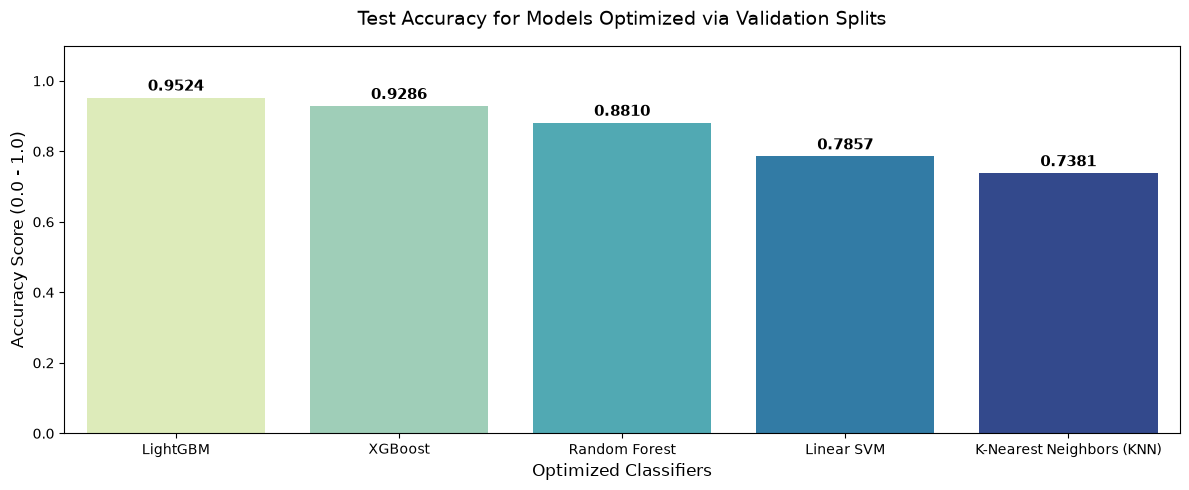

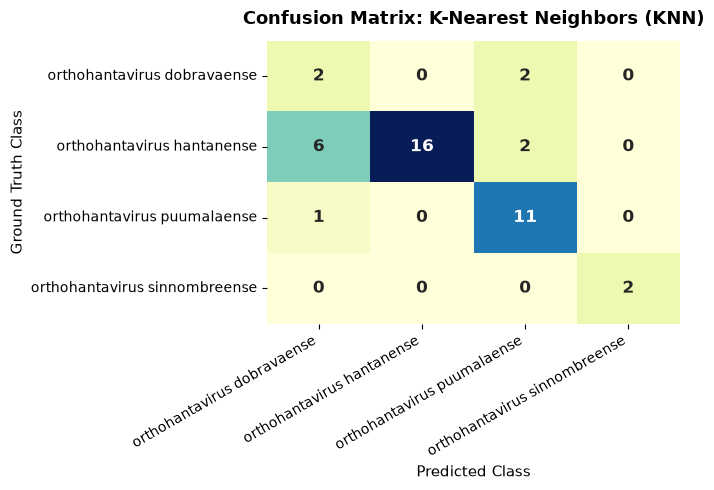

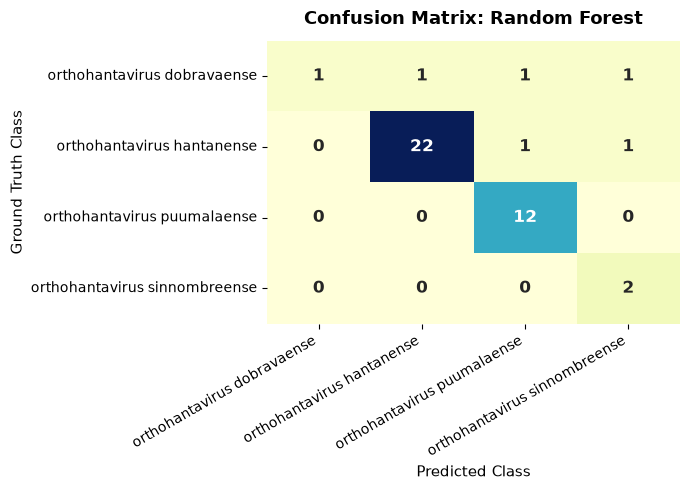

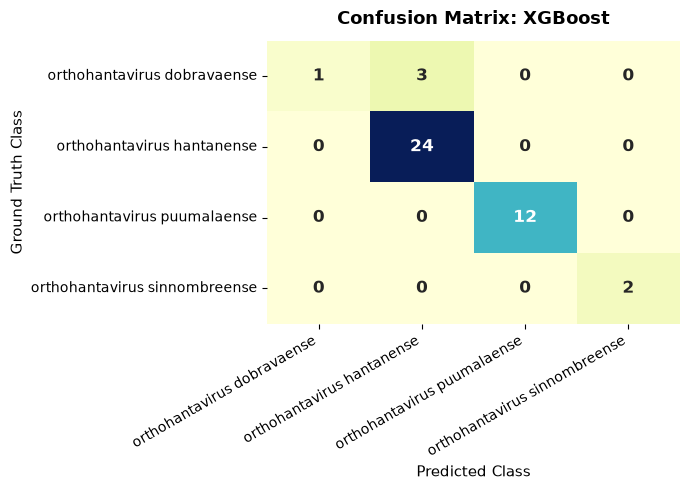

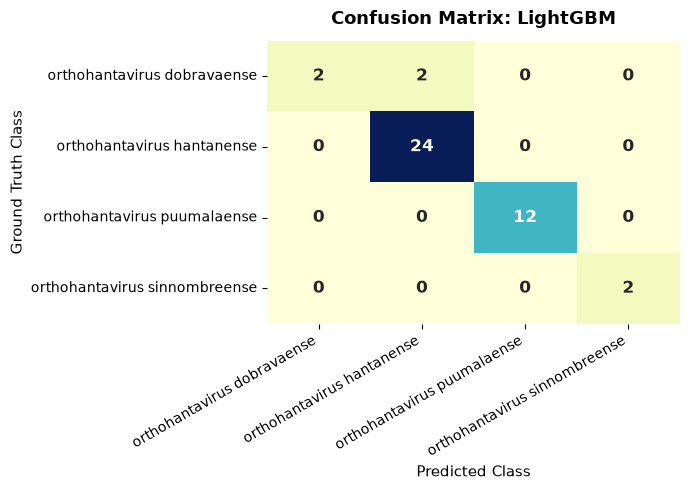

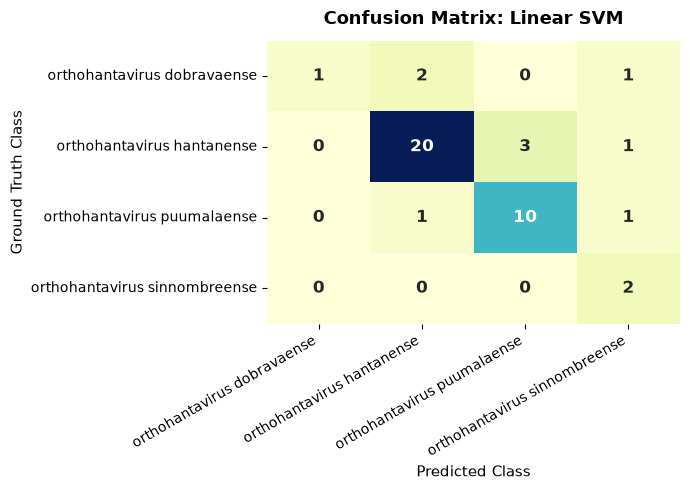

In [234]:
train_and_evaluate(df, feature_names)

## Feature selection

Original number of features: 71
Updated number of features: 52


Class distribution in the resampled training labels:
orthohantavirus dobravaense: 196
orthohantavirus hantanense: 196
orthohantavirus puumalaense: 196
orthohantavirus sinnombreense: 196

Starting hyperparameter tuning and model training...

Optimal K-Nearest Neighbors (KNN) parameters: {'n_neighbors': 3, 'weights': 'uniform'}
Optimal Random Forest parameters: {'max_depth': 10, 'min_samples_split': 2}
Optimal XGBoost parameters: {'max_depth': 3, 'learning_rate': 0.03, 'n_estimators': 481}
Optimal LightGBM parameters: {'num_leaves': 15, 'learning_rate': 0.01}
Optimal Linear SVM parameters: {'C': 0.1}

Confusion Matrices:
Final Evaluation for optimized model: K-Nearest Neighbors (KNN)
                               precision    recall  f1-score   support

  orthohantavirus dobravaense       0.14      0.25      0.18         4
   orthohantavirus hantanense       0.94      0.67      0.78        24
  orthohantavirus puumalaense 

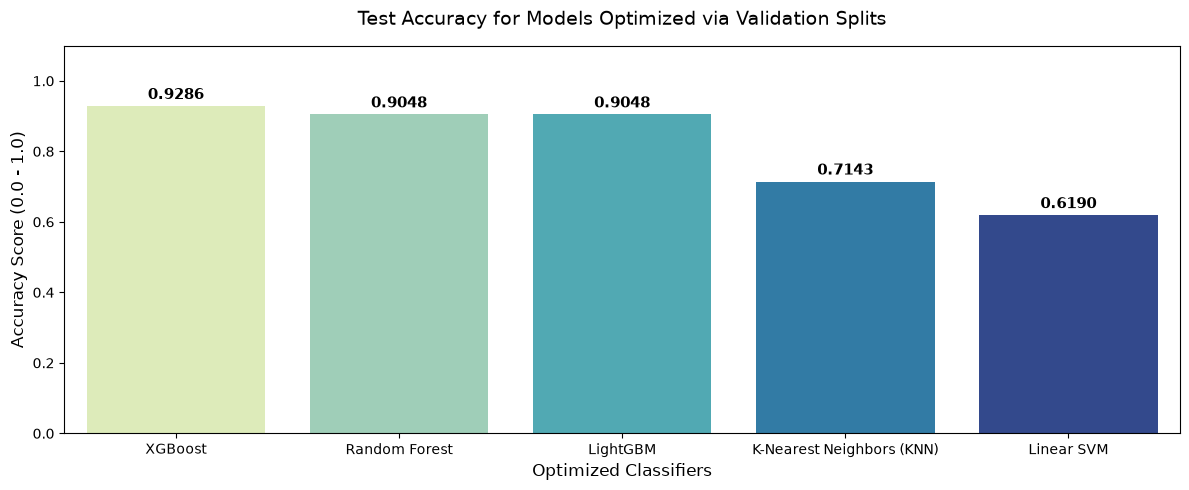

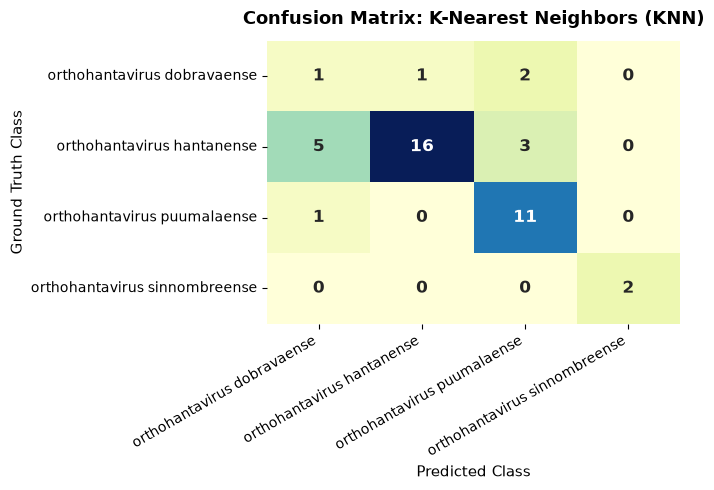

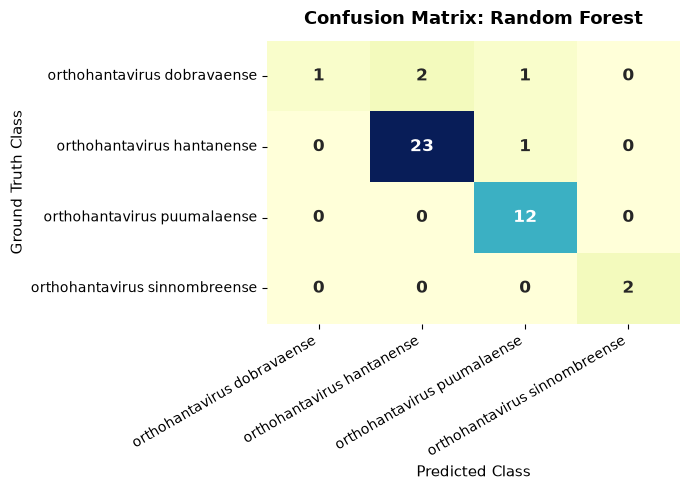

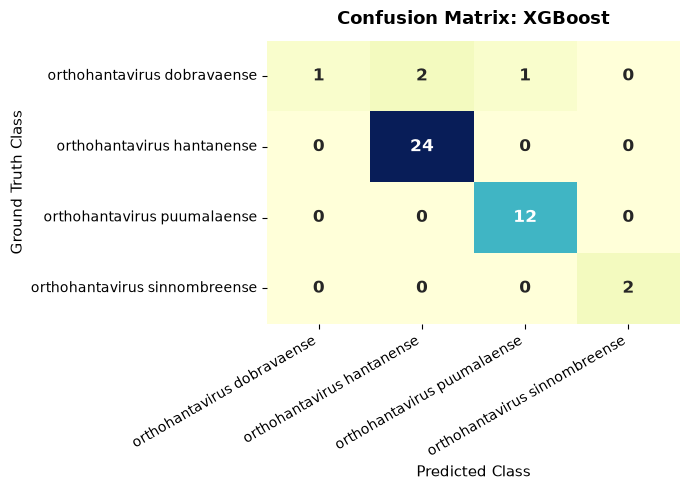

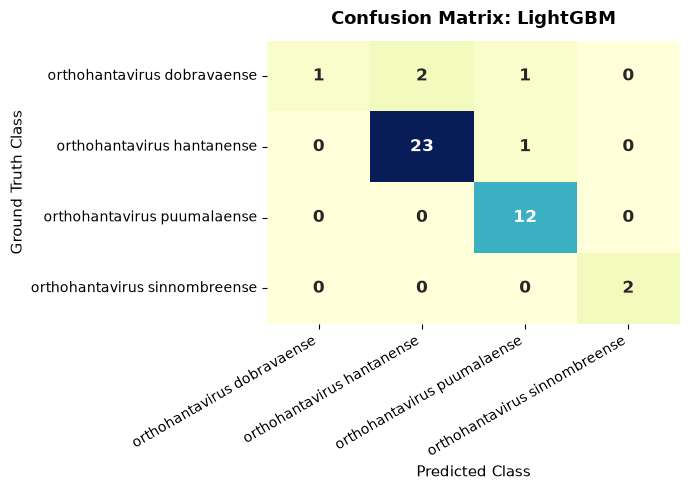

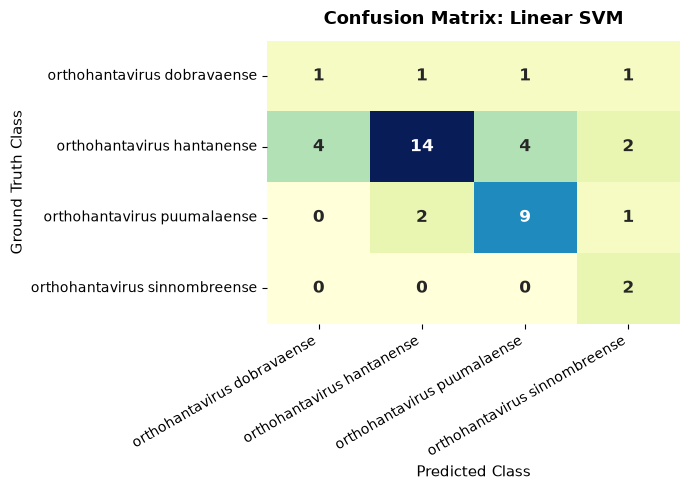

In [235]:
df_without_corr, feature_names_without_corr = drop_low_correlation_features(df, feature_names)
train_and_evaluate(df_without_corr, feature_names_without_corr)